# CELE ZASTOSOWANIA INTERPOLACJI I APROKSYMACJI

W ramach interpolacji i aproksymacji omówimy trzy główne zastosowania:

1. **Reprodukcja kształtu funkcji** — odtworzenie nieznanej funkcji na podstawie dyskretnych pomiarów (1D).
2. **Określenie parametrów modelu** — dopasowanie modelu analitycznego do danych eksperymentalnych.
3. **Interpolacja 2D** — dyskretna reprezentacja na siatce dwuwymiarowej.

---

**Załączamy niezbędne biblioteki i generujemy dane.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, make_interp_spline, griddata, PchipInterpolator

# Węzły interpolacji
a, b = 1, 10
N = 9
x = np.linspace(a, b, N)
f = lambda x: (np.log(x) * np.sin(x) / x)**2
y = f(x)

# Gęsta siatka do wykresów
xx = np.linspace(a, b, 101)

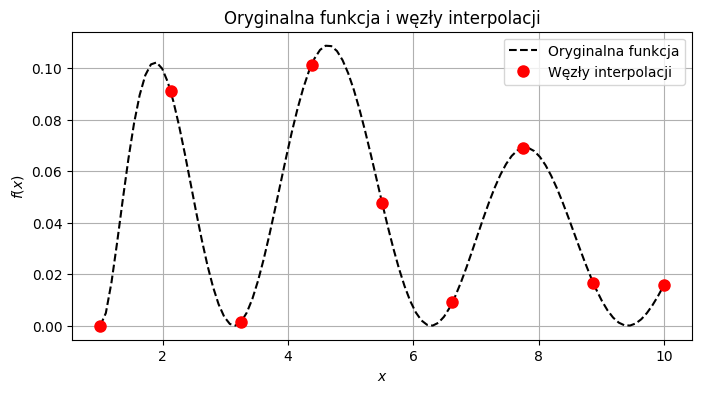

In [2]:
plt.figure(figsize=(8, 4))
plt.plot(xx, f(xx), 'k--', label='Oryginalna funkcja')
plt.plot(x, y, 'ro', markersize=8, label='Węzły interpolacji')
plt.grid(True)
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Oryginalna funkcja i węzły interpolacji')
plt.show()

## 1. Reprodukcja kształtu funkcji (1D)

Wykonamy interpolację wielomianową oraz spline'em kubicznym.

Interpolacja wielomianowa: rozwiązujemy układ $Ax = y$ gdzie $A$ to macierz Vandermonde'a. W praktyce korzystamy z `np.polyfit`.

Interpolacja spline'em kubicznym: `scipy.interpolate.make_interp_spline`.

In [3]:
# Interpolacja wielomianowa
coeffs_poly = np.polyfit(x, y, N - 1)
y_poly = np.polyval(coeffs_poly, xx)

# Interpolacja spline kubicznym
spline = make_interp_spline(x, y, k=3)
y_spline = spline(xx)

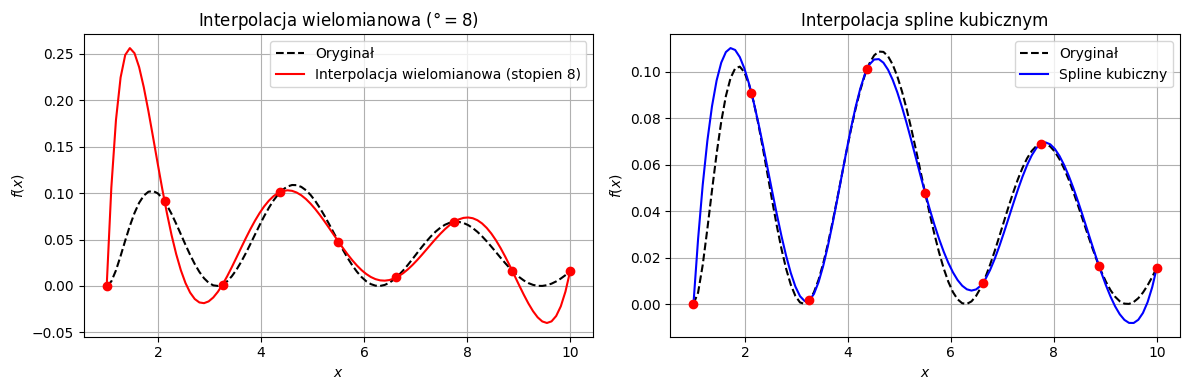

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

deg_label = f'Interpolacja wielomianowa (stopien {N-1})'
ax[0].plot(xx, f(xx), 'k--', label='Oryginał')
ax[0].plot(xx, y_poly, 'r-', label=deg_label)
ax[0].plot(x, y, 'ro')
ax[0].set_title(f'Interpolacja wielomianowa ($\\degree = {N-1}$)')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$f(x)$')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(xx, f(xx), 'k--', label='Oryginał')
ax[1].plot(xx, y_spline, 'b-', label='Spline kubiczny')
ax[1].plot(x, y, 'ro')
ax[1].set_title('Interpolacja spline kubicznym')
ax[1].set_xlabel('$x$')
ax[1].set_ylabel('$f(x)$')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Widzimy, że interpolacja wielomianowa wyższego stopnia wykazuje oscylacje (zjawisko Rungego), podczas gdy spline kubiczny lepiej reprodukuje kształt funkcji.

## 2. Określenie parametrów modelu — termopara

Przykład z termopary: znamy temperaturę $T$ i napięcie $U$, chcemy znaleźć liniową zależność $U = U_0 + \\alpha T$.

In [5]:
# Dane termopary
Temp = np.array([50, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
Voltage = np.array([2.6, 6.7, 8.8, 11.2, 17, 22.5, 26, 32.5, 37.7, 41, 48, 55.2]) * 1e-3

# Aproksymacja liniowa (dopasowanie do modelu U = U0 + alpha*T)
wsp = np.polyfit(Temp, Voltage, 1)
alpha = wsp[0]
U0 = wsp[1]

print(f"Parametr właściwościowy: alpha = {alpha:.4e} V/K")
print(f"U0 = {U0:.4e} V")

Parametr właściwościowy: alpha = 5.2831e-05 V/K
U0 = 6.7202e-04 V


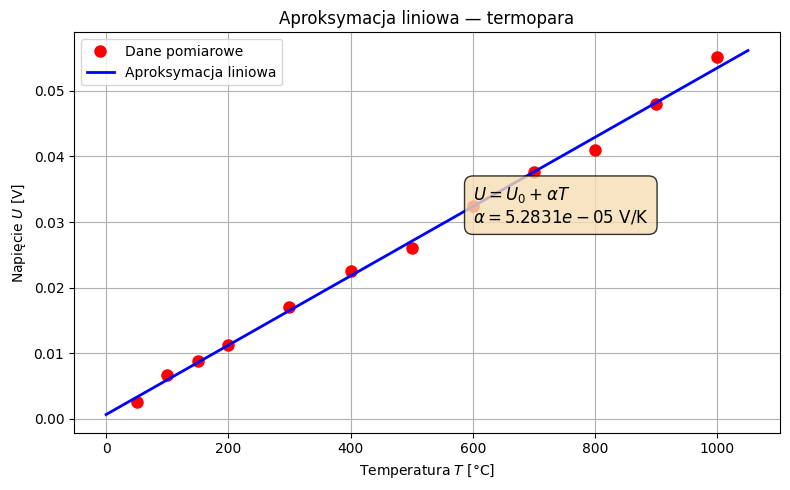

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Temp, Voltage, 'ro', markersize=8, label='Dane pomiarowe')
T_fit = np.linspace(0, 1050, 100)
ax.plot(T_fit, wsp[0] * T_fit + wsp[1], 'b-', linewidth=2, label='Aproksymacja liniowa')
ax.annotate(f'$U = U_0 + \\alpha T$\n$\\alpha = {alpha:.4e}$ V/K',
             xy=(600, 30e-3), fontsize=12,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8))
ax.set_xlabel('Temperatura $T$ [°C]')
ax.set_ylabel('Napięcie $U$ [V]')
ax.set_title('Aproksymacja liniowa — termopara')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Drugi przykład — dane bez ścisłego modelu matematycznego

Powyższe podejście (aproksymacja liniowa) stosuje się też szeroko do analizy danych nieposiadających ścisłych matematycznych modeli, np. danych z zakresu nauk ekonomicznych, biologicznych czy socjalnych. Poniżej dane z badania objętości płuc u dzieci (wiek w latach, objętość w litrach). Naszym celem jest znalezienie ogólnej reguły (na razie nie przejmujemy się rozrzutem danych).

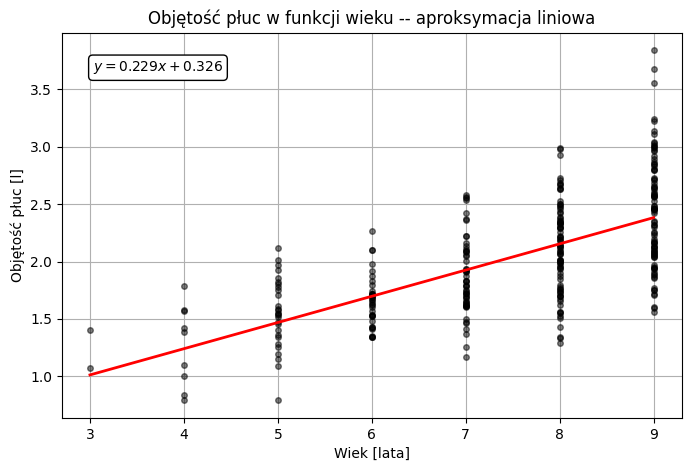

In [7]:
# Dane: objętość płuc w funkcji wieku (309 pomiarów)
Age = np.array([
    9, 8, 7, 9, 9, 8, 6, 6, 8, 9, 6, 8, 8, 8, 8, 7, 5, 6, 9, 9,
    5, 5, 4, 7, 9, 3, 9, 5, 8, 9, 5, 9, 8, 7, 5, 8, 9, 8, 8, 8,
    9, 8, 5, 8, 5, 9, 7, 8, 6, 8, 5, 9, 9, 8, 6, 9, 9, 7, 4, 8,
    8, 8, 6, 4, 8, 6, 9, 7, 5, 9, 8, 8, 9, 9, 9, 7, 5, 5, 9, 6,
    7, 6, 8, 8, 7, 8, 7, 9, 5, 9, 9, 9, 7, 8, 8, 9, 9, 9, 7, 8,
    8, 7, 9, 4, 9, 6, 8, 6, 7, 7, 8, 7, 7, 7, 7, 8, 7, 5, 8, 7,
    9, 7, 7, 6, 8, 8, 8, 9, 7, 8, 9, 8, 8, 9, 8, 6, 6, 8, 9, 5,
    7, 9, 6, 9, 9, 9, 6, 8, 9, 8, 8, 9, 9, 9, 7, 8, 6, 9, 9, 9,
    7, 8, 5, 8, 9, 6, 9, 6, 8, 5, 7, 7, 4, 9, 8, 9, 9, 9, 5, 9,
    7, 6, 9, 9, 9, 7, 5, 8, 9, 7, 9, 8, 9, 6, 6, 8, 9, 5, 6, 6,
    9, 7, 9, 8, 5, 7, 6, 9, 7, 9, 9, 8, 9, 7, 9, 4, 9, 5, 8, 9,
    8, 3, 9, 8, 6, 9, 8, 8, 7, 6, 8, 9, 4, 7, 8, 8, 9, 6, 8, 6,
    8, 9, 8, 7, 9, 8, 7, 9, 8, 9, 6, 8, 9, 8, 9, 9, 8, 7, 5, 7,
    8, 9, 9, 6, 8, 7, 9, 7, 7, 5, 9, 9, 8, 8, 9, 6, 7, 5, 9, 5,
    7, 6, 8, 7, 8, 4, 8, 5, 8, 7, 7, 9, 9, 8, 9, 6, 8, 9, 4, 6,
    7, 9, 8, 6, 8, 7, 5, 8, 7,
])
Vol = np.array([
    1.708, 1.724, 1.720, 1.558, 1.895, 2.336, 1.919, 1.415,
    1.987, 1.942, 1.602, 1.735, 2.193, 2.118, 2.258, 1.932,
    1.472, 1.878, 2.352, 2.604, 1.400, 1.256, 0.839, 2.578,
    2.988, 1.404, 2.348, 1.755, 2.980, 2.100, 1.282, 3.000,
    2.673, 2.093, 1.612, 2.175, 2.725, 2.071, 1.547, 2.004,
    3.135, 2.420, 1.776, 1.931, 1.343, 2.076, 1.624, 1.344,
    1.650, 2.732, 2.017, 2.797, 3.556, 1.703, 1.634, 2.570,
    3.016, 2.419, 1.569, 1.698, 2.123, 2.481, 1.481, 1.577,
    1.940, 1.747, 2.069, 1.631, 1.536, 2.560, 1.962, 2.531,
    2.715, 2.457, 2.090, 1.789, 1.858, 1.452, 3.842, 1.719,
    2.111, 1.695, 2.211, 1.794, 1.917, 2.144, 1.253, 2.659,
    1.580, 2.126, 3.029, 2.964, 1.611, 2.215, 2.388, 2.196,
    1.751, 2.165, 1.682, 1.523, 1.292, 1.649, 2.588, 0.796,
    2.574, 1.979, 2.354, 1.718, 1.742, 1.603, 2.639, 1.829,
    2.084, 2.220, 1.473, 2.341, 1.698, 1.196, 1.872, 2.219,
    2.420, 1.827, 1.461, 1.338, 2.090, 1.697, 1.562, 2.040,
    1.609, 2.458, 2.650, 1.429, 1.675, 1.947, 2.069, 1.572,
    1.348, 2.288, 1.773, 0.791, 1.905, 2.463, 1.431, 2.631,
    3.114, 2.135, 1.527, 2.293, 3.042, 2.927, 2.665, 2.301,
    2.460, 2.592, 1.750, 1.759, 1.536, 2.259, 2.048, 2.571,
    2.046, 1.780, 1.552, 1.953, 2.893, 1.713, 2.851, 1.624,
    2.631, 1.819, 1.658, 2.158, 1.789, 3.004, 2.503, 1.933,
    2.091, 2.316, 1.704, 1.606, 1.165, 2.102, 2.320, 2.230,
    1.716, 1.790, 1.146, 2.187, 2.717, 1.796, 1.953, 1.335,
    2.119, 1.666, 1.826, 2.709, 2.871, 1.092, 2.262, 2.104,
    2.166, 1.690, 2.973, 2.145, 1.971, 2.095, 1.697, 2.455,
    1.920, 2.164, 2.130, 2.993, 2.529, 1.726, 2.442, 1.102,
    2.056, 1.808, 2.305, 1.969, 1.556, 1.072, 2.042, 1.512,
    1.423, 3.681, 1.991, 1.897, 1.370, 1.338, 2.016, 2.639,
    1.389, 1.612, 2.135, 2.681, 3.223, 1.796, 2.010, 1.523,
    1.744, 2.485, 2.335, 1.415, 2.076, 2.435, 1.728, 2.850,
    1.844, 1.754, 1.343, 2.303, 2.246, 2.476, 3.239, 2.457,
    2.382, 1.640, 1.589, 2.056, 2.226, 1.886, 2.833, 1.715,
    2.631, 2.550, 1.912, 1.877, 1.935, 1.539, 2.803, 2.923,
    2.358, 2.094, 1.855, 1.535, 2.135, 1.930, 2.182, 1.359,
    2.002, 1.699, 2.500, 2.366, 2.069, 1.418, 2.333, 1.514,
    1.758, 2.535, 2.564, 2.487, 1.591, 1.624, 2.798, 1.691,
    1.999, 1.869, 1.004, 1.427, 1.826, 2.688, 1.657, 1.672,
    2.015, 2.371, 2.115, 2.328, 1.495,
])

# Wykreślmy dane -- zwróć uwagę, że to NIE jest funkcja: dla każdego wieku
# mamy wiele różnych wartości objętości (wiele dzieci w tym samym wieku)
plt.figure(figsize=(8, 5))
plt.plot(Age, Vol, 'ko', markersize=4, alpha=0.5)
plt.xlabel('Wiek [lata]')
plt.ylabel('Objętość płuc [l]')

# Interpolacja i aproksymacja wyglądają podobnie, ale są zdefiniowane
# zupełnie inaczej. Z tym problemem interpolacja nie mogłaby sobie
# poradzić -- żadna funkcja nie może przejść przez wszystkie punkty
# (dla jednego x mamy wiele różnych y). Aproksymacja radzi sobie z tym
# znakomicie i dlatego jest najczęściej wykorzystywana przy identyfikacji
# parametrów modelu.
wsp = np.polyfit(Age, Vol, 1)
age_fit = np.linspace(Age.min(), Age.max(), 100)
plt.plot(age_fit, np.polyval(wsp, age_fit), 'r-', linewidth=2)
plt.annotate(f'$y={wsp[0]:.3f}x+{wsp[1]:.3f}$', xy=(0.05, 0.9), xycoords='axes fraction',
             bbox=dict(boxstyle='round', facecolor='white'))
plt.title('Objętość płuc w funkcji wieku -- aproksymacja liniowa')
plt.grid(True)
plt.show()

# Widzimy w ten sposób, jaka jest średnia objętość płuc w populacji w
# skali wieku -- to już cenna i użyteczna informacja. Model (liniowy)
# przyjęliśmy arbitralnie -- nie ma żadnego fizycznego uzasadnienia, że
# zależność MUSI być liniowa. Jest to stricte matematyczne modelowanie.

### Aproksymacja a regresja

Aproksymacja i regresja to nie to samo. Zagadnienie regresji, oprócz metod wyznaczania współczynników modelu, potrafi też oszacować statystyczne właściwości problemu -- takie jak średnie i maksymalne odchylenie od wartości średniej, czy jakość odwzorowania wyrażoną odpowiednimi miarami statystycznymi (np. $R^2$).

Przykładowo w problemie objętości płuc w funkcji wieku za pomocą aproksymacji uzyskaliśmy parametry modelu liniowego. Nie wiemy natomiast, czy jest to wartość wiarygodna, jaki jest zakres, który można uznać za akceptowalny, ani jakie wyniki powinny nas zaniepokoić.

Regresja jest więc zagadnieniem szerszym, choć w pewnych przypadkach korzysta z aproksymacji. Można powiedzieć, że aproksymacja to szczególny, prosty przypadek regresji w zakresie wyznaczania parametrów modelu -- ale ma liczne ograniczenia (głównie: konieczność przyjęcia z góry konkretnej postaci funkcji jako stałego parametru), co nie zawsze pasuje do różnych modeli. Dlatego metody regresyjne są zazwyczaj bardziej złożone niż sama aproksymacja.

## 3. Interpolacja 2D — `griddata`

Interpolacja dwuwymiarowa: dyskretna reprezentacja na siatce.

Korzystamy z `scipy.interpolate.griddata` — może wykonywać interpolację liniową, kubiczną ('cubic') lub najbliższego sąsiada ('nearest').

In [8]:
# Tworzenie siatki i danych
N2d = 0.8
x_grid, y_grid = np.meshgrid(np.arange(-2, 2.1, N2d), np.arange(-2, 2.1, N2d))
v = np.abs(x_grid * np.exp(-(x_grid**2 + y_grid**2)))

# Siatka docelowa (gęstsza)
xq, yq = np.meshgrid(np.arange(-2, 2.1, 0.2), np.arange(-2, 2.1, 0.2))

# Interpolacja kubiczna
vq_cubic = griddata((x_grid.ravel(), y_grid.ravel()), v.ravel(),
                     (xq, yq), method='cubic')

# Interpolacja liniowa
vq_linear = griddata((x_grid.ravel(), y_grid.ravel()), v.ravel(),
                      (xq, yq), method='linear')

# Interpolacja najblizszego sasiedzia
vq_nearest = griddata((x_grid.ravel(), y_grid.ravel()), v.ravel(),
                       (xq, yq), method='nearest')

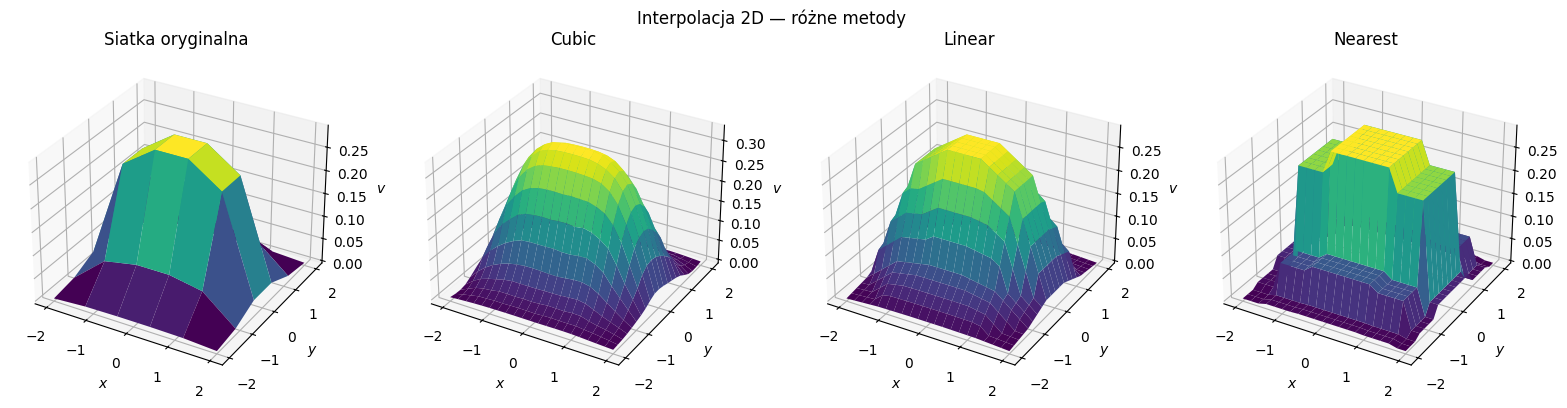

In [9]:
# Siatka oryginalna
fig = plt.figure(figsize=(16, 4))

ax1 = fig.add_subplot(141, projection='3d')
ax1.plot_surface(x_grid, y_grid, v, cmap='viridis', edgecolor='none')
ax1.set_title('Siatka oryginalna')
ax1.set_xlabel('$x$'); ax1.set_ylabel('$y$'); ax1.set_zlabel('$v$')

# Cubic
ax2 = fig.add_subplot(142, projection='3d')
ax2.plot_surface(xq, yq, vq_cubic, cmap='viridis', edgecolor='none')
ax2.set_title('Cubic')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$'); ax2.set_zlabel('$v$')

# Linear
ax3 = fig.add_subplot(143, projection='3d')
ax3.plot_surface(xq, yq, vq_linear, cmap='viridis', edgecolor='none')
ax3.set_title('Linear')
ax3.set_xlabel('$x$'); ax3.set_ylabel('$y$'); ax3.set_zlabel('$v$')

# Nearest
ax4 = fig.add_subplot(144, projection='3d')
ax4.plot_surface(xq, yq, vq_nearest, cmap='viridis', edgecolor='none')
ax4.set_title('Nearest')
ax4.set_xlabel('$x$'); ax4.set_ylabel('$y$'); ax4.set_zlabel('$v$')

plt.suptitle('Interpolacja 2D — różne metody')
plt.tight_layout()
plt.show()

---

## Ćwiczenia

**Ćwiczenie 1:** Zmień liczbę węzłów `N` w pierwszym przykładzie (np. $N=5, 11, 21$). Zauważ jak zmienia się jakość interpolacji wielomianowej i spline'a.

**Ćwiczenie 2:** Zmień funkcję `f` na inną (np. $f(x) = \\sin(\\pi x)$, $f(x) = e^{-x}$). Sprawdź, która metoda interpolacji radzi sobie lepiej.

**Ćwiczenie 3:** Zmień sposób generowania punktów — zamiast równomiernego, użyj węzłów Czebyszowa:

$$ x_k = \\frac{a+b}{2} + \\frac{b-a}{2} \\cos\\left(\\frac{(2k+1)\\pi}{2N}\\right) $$

Sprawdź, czy zmniejsza się zjawisko Rungego.